# Exercise 1

Deadline 6.11.2025

Anna Bütfering

Lea Neumann

Juan Provencio

## 1. Two dimensional data

In [3]:
from sklearn.datasets import make_moons
import numpy as np
import matplotlib.pyplot as plt

from numpy import exp, sqrt, pi

In [7]:
# Plot
X, y = make_moons(n_samples = 500, noise = 0.1, random_state = 42)
plt.scatter(X[:, 0], X[:, 1], s=10)

# Implement a class for each of the following models, including
# methods for fit(), sample(), and score_samples()

<div style="color: green; font-weight: bold">
This was not included in the lecture, but it gives some idea of what the true data looks like.
</div>

Next, we will implement classes, à la sklearn, providing methods for fit(), sample() and score_samples() without using the pre-defined classes, but formulating them independently.

We will create a class for each of the following models:

1. two-dimensional histogram
2. single Gaussian
3. Gaussian mixture model
4. kernel density estimator with a Gaussian kernel

For evaluation, we will implement the maximum mean discrepancy metric with squared exponential and inverse multi-quadratic kernels

$$ \mathrm{se}(x, x') = \mathrm{exp}(-\dfrac{||{x-x'}||^2}{h^2})$$

$$ \mathrm{imq}(x, x') = \dfrac{1}{\sqrt{1 + \dfrac{||{x-x'}||^2}{h^2}}}$$

### 1.1 Two dimensional histogram

<div style="color: green; font-weight: bold">

## OVERALL COMMENTS: 

We did not implement explicit speed comparisons for the different models and functions, but we made sure to use numpy vectorization where possible.
To compare the models, it would have been more elegant to implement each class and then plot/evaluate them side-to-side. Still this is more a question of presentation of our solutions. The content of our soltions is commented below and the models are evaluated one-by-one in detail.

### Model evaluation via squared MMD
We implemented an MMD function for the 2D-Histogram, single Gaussian and GMM, which leads to some redundancy. Yet, this way each model is self-contained and can be used independently. 
KDE was not implemented with MMD computation. Here, making one global MMD function would have saved time and would have made the code more concise.

MMD2 IMPLEMENTATION: 
- We used the ‘expansion of the squared norm’ apporach, as shown in the solution and implemented it essentially in the same way. 
- We separated the calculations in different functions: 
    calculate_distance_matrix() to compute the squared euclidian distance between all pairs of data points, as well as 
    squared_exponential() and inverse_multi_audratic() for the according kernel function. 
    In the compute_mmd() function, we calculate the mean distance by summing up the outcomes of the kernel functions and dividing by N’^2 or NN’. This is equivalent to the usage of np.mean in the given solution. 
- We did not include a function approximating the MMD^2 for infinite samples (by averaging over multiple distributions). 

We left out the term for the self-similarity of the true data, because, as explained in the lecture, it is model-independent. Therefore, our MMD^2 calculation approach has a downward bias, meaning that results <0 are possible and indicate a better model quality - to a certain extent.
The positive term for self-similarity of the  predicted data should be minimized (i.e. points are far apart and cover the whole data range of X_true) and the negative term for the cross-similarity should be as large as possible, meaning that the points (almost) coincide. This means that with our calculation, negative MMD^2 values indicate a better model fit. 

However, the effect of the bandwidth has to be considered. As mentioned in our original submission, the models with large bandwidth seem to converge much faster to a constant MMD^2 value. This shows the loss of sensitivity of the MMD with bigger bandwidth, that can oversmooth and miss differences between the data sets. With smaller bandwidths, the kernel function may overfit to noise. This can be observed in our diagram for GMMs, that includes the Single Gaussian with M = 1. The models achieve much worse results with lower h, but the differences in model quality due to training set size are much better visualized.

Using the MMD^2 of the true distribution only, would have been a good test to check what values would be desirable for the MMD^2 of the models. Still, this is not necessary to compare the models among each other.


## 2D-Histogram:
We use two vectors for bin_edges_1/2, instead of a single tuple, this requires more code, but has essentially the same functionality.
Overall, our implementation is very similar to the solution, but with some differences in structure and with some additional class properties.
 #### Question: overall more properties for this class, some of which might have been left out? Should be fine overall tho

FIT():
- We included the option to calculate bin_size and thus number of bins, as explained in the lecture. This may require more calculations, but is also more methematically stringent.
- Using np.linspace instead of np.arrange might have been more elegant, but does not change functionality and is not expected to impact the calculation speed. Since our code is not significantly more complex and does not use loops, it should be equivalent.
- Our fit function calculates self.densities and self.bin_edges_1/2, hence, it has pretty much the same functionality as the given solution.

PREDICT()/SCORE_SAMPLES():
- Our score_samples() function returns log densities, as in the sklearn API. Even though the predict() function returns densities, score_samples() is still a valid way to compare model quality (via MMD^2), since we implemented this logic throughout all models. 
- We also have a test for whether indices are inside the bin range ('valid mask'). In the solution, this functionality is implied by the 'for' loop with the boolean condition. 

SAMPLE():

    #### Question: In the solution: fit() method divides the self.histogram values (N_l) by their sum (N), which should give the probability values. Then they calculate the 'bin_probabilities' again in sample(). Does that even make sense??
    
- As specified in the exercise, a bin is chosen first based on the calculated probabilities (self.densities), then a sample is drawn uniformly from within the bin. This is equivalent to the solution.
- We did not implement an additional noise option when sampling, as it was not specified in the exercise.

MMD2 and Model Evaluation:
- See Overall Comments above.
</div>

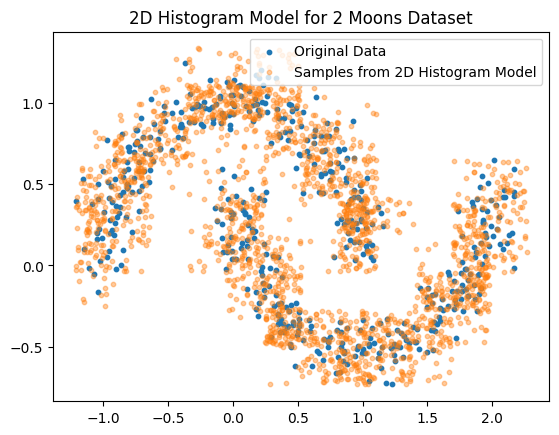

In [6]:
class two_dim_histogram:
    def __init__(self, random_state=None, bin_size=None):
        self.densities = None
        self.bin_edges_1 = None
        self.bin_edges_2 = None
        self.samples = None
        self.score = None
        self.log_density = None
        self.bin_indices = None
        self.bin_size = bin_size
        self.MMD_sq = None
        self.random_state = np.random.RandomState(random_state) if random_state is not None else np.random
    # Method to fit 2d histogram
    '''
    As in 1d, need to determine p_k and bin sizes.
    
    In 1d, determined the bin sizes with the interquantile range IQR

        h_1D = 2 IQR / (N)^(1/3)

    In 2d, do the same in both dimensions
    '''
    def fit(self, X): # training_data := X
        # Get n_samples
        n_samples = X.shape[0]

        # Determine Interquantile range
        # IQR = x_[3N/4] - x_[N/4]
        """
        DONT WANT TO GIVE PEOPLE THE OPTION TO PICK THEIR OWN BINS BECAUSE
        IM TOO TIRED 
        UGHH OK I NEED TO
        """
        if self.bin_size == None:
            IQR_x1 = np.percentile(X[:, 0], 75) - np.percentile(X[:, 0], 25)
            IQR_x2 = np.percentile(X[:, 1], 75) - np.percentile(X[:, 1], 25)

            # Bin widths
            h_1 = 2 * IQR_x1 / ((n_samples) ** (1/3))
            h_2 = 2 * IQR_x2 / ((n_samples) ** (1/3))
            self.bin_size = (np.round(h_1, 2), np.round(h_2, 2))

            # Create bins k
            x1_min, x1_max = np.min(X[:, 0]), np.max(X[:, 0])
            x2_min, x2_max = np.min(X[:, 1]), np.max(X[:, 1])
            self.bin_edges_1 = np.arange(x1_min, x1_max + self.bin_size[0], self.bin_size[0])
            self.bin_edges_2 = np.arange(x2_min, x2_max + self.bin_size[1], self.bin_size[1])
        else:
            x1_min, x1_max = np.min(X[:, 0]), np.max(X[:, 0])
            x2_min, x2_max = np.min(X[:, 1]), np.max(X[:, 1])
            self.bin_edges_1 = np.arange(x1_min, x1_max + self.bin_size[0], self.bin_size[0])
            self.bin_edges_2 = np.arange(x2_min, x2_max + self.bin_size[1], self.bin_size[1])
        
        # Determine counts in bins k
        counts, _, _ = np.histogram2d(X[:, 0], X[:, 1], bins = [self.bin_edges_1, self.bin_edges_2])
        self.densities = counts / counts.sum()

        return self.densities, self.bin_edges_1, self.bin_edges_2

    # Sample
    def sample(self, n_samples=1):
        # now we can draw samples from the learned histogram (generated new data points)
        probs_flat = self.densities.ravel()    # flatten the 2D probs array to 1D
        self.bin_indices = self.random_state.choice(probs_flat.size, size=n_samples, p=probs_flat)
        ix, iy = np.unravel_index(self.bin_indices, self.densities.shape) # convert flat indices back to 2D indices
        x0 = self.bin_edges_1[ix]
        x1 = self.bin_edges_1[ix + 1]
        y0 = self.bin_edges_2[iy]
        y1 = self.bin_edges_2[iy + 1]

        x_samples = x0 + self.random_state.rand(n_samples) * (x1 - x0)
        y_samples = y0 + self.random_state.rand(n_samples) * (y1 - y0)

        self.samples = np.column_stack([x_samples, y_samples])  # shape (n_samples, 2)

        return self.samples

    # Method to score samples
    def score_samples(self, X):
        """Compute the log density for each point in X."""
        if self.densities is None or self.bin_edges_1 is None or self.bin_edges_2 is None:
            raise ValueError("Model is not fitted. Call the `fit` method first.")

        # Find the bin indices for each point in X
        bin_indices_x = np.digitize(X[:, 0], self.bin_edges_1) - 1
        bin_indices_y = np.digitize(X[:, 1], self.bin_edges_2) - 1

        # Ensure indices are within range
        valid_mask = (
            (bin_indices_x >= 0) & (bin_indices_x < self.densities.shape[0]) &
            (bin_indices_y >= 0) & (bin_indices_y < self.densities.shape[1])
        )

        # Initialize log densities with -inf for points outside the histogram range
        self.log_densities = np.full(X.shape[0], -np.inf)

        # Assign log densities for valid points
        self.log_densities[valid_mask] = np.log(
            self.densities[bin_indices_x[valid_mask], bin_indices_y[valid_mask]]
        )

        return self.log_densities
        

    
    # Compute mmd^2
    def compute_mmd(self, X, h = 1, kernel = "squared_exponential"):
        if self.samples is None:
            raise ValueError("Samples are not generated. Call the `sample` method before scoring.")
        # Implement MMD^2 metric with se, imq kernels
        # Need to vectorize MMD calculation because for loops (sums) are very inefficient in python
        # MMD^2 = Term1 + Term2 - Term3, can neglect Term1 because it is model independent
        """
        MMD^2 = 0
        for i in range(1,N):
            for i_prime != i:
                MMD^2 += k(x_i, x_i_prime)

        for j in range(1, N_prime):
            for j_prime != j:
                MMD^2 += k(x_prime_j, x_prime_j_prime)

        for i in range(1, N):
            for j in range(1, N_prime):
                MMD^2 += -2 k(x_i, x_prime_j)
        """
        # Instead, we want to calculate it using something like this:
        """
        MMD^2 = k(distance_matrix_x).sum() 
            + k(distance_matrix_x_prime).sum() 
            - 2 k(distance_matrix_xx_prime).sum()
        """
        # Calculate Distance matrices D as: 
        # D[i, j] = || x_i - x_i_prime ||_2^2 = ||x||_2^2 + ||x_prime||_2^2 - 2 x.T @ x_prime
        # D_XX = self.calculate_distance_matrix(X, X) Can be neglected
        D_XprimeXprime = self.calculate_distance_matrix(self.samples, self.samples)
        D_XXprime = self.calculate_distance_matrix(X, self.samples)

        # Depending on selected kernel, calculate MMD^2
        N = X.shape[0]
        Nprime = self.samples.shape[0]
        if kernel == "squared_exponential":
            self.MMD_sq = (self.squared_exponential(D_XprimeXprime, h).sum() / (Nprime ** 2)
                      - 2 * self.squared_exponential(D_XXprime, h).sum() / (N * Nprime))
        elif kernel == "inverse_multi_quadratic":
            self.MMD_sq = (self.inverse_multi_quadratic(D_XprimeXprime, h).sum() / (Nprime ** 2)
                      - 2 * self.inverse_multi_quadratic(D_XXprime, h).sum() / (N * Nprime))
        else:
            raise ValueError("Please select either 'squared_exponential' or 'inverse_multi_quadratic'")
        """
        In the lecture we derived the formula where we sum over i, then sum over i != j. The kernels 
        k(i, i) are not 0, but 1. We still sum over them in the vectorization. For that reason, 
        we adjust the denominator to N^2, N'^2 instead of N(N-1), N'(N'-1)
        """

        self.MMD_sq

        return self.MMD_sq
    
    def calculate_distance_matrix(self, A, B):
        # D_ij = ||A_i - B_j||^2 = ||A_i||^2 + ||B_j||^2 - 2 A_i @ B_j.T
        # A_sq in (N_A, 1)
        A_sq = np.sum(A ** 2, axis = 1, keepdims = True)
        # B_sq in (1, N_B)
        B_sq = np.sum(B ** 2, axis = 1, keepdims = True).T # .T otherwise won't work if samples, data different dimension
        AB_T = A @ B.T
        D_AB = A_sq + B_sq - 2 * AB_T
        return D_AB
        
    def squared_exponential(self, D_AB, h):
        return exp(- D_AB / (h ** 2))   
    
    def inverse_multi_quadratic(self, D_AB, h):
        return 1 / sqrt(1 + D_AB / (h ** 2))

# Fit 2d histogram model
model = two_dim_histogram()
model.fit(X)
model.sample(2000)
model.score_samples(X)

make_moons_histogram2d, edges_1, edges_2 = model.fit(X)

# Sample from fitted model
X_samples = model.sample(n_samples = 2000)  

# Plot
plt.figure()
plt.title("2D Histogram Model for 2 Moons Dataset")
plt.scatter(X[:, 0], X[:, 1], s=10, label = "Original Data")
plt.scatter(X_samples[:, 0], X_samples[:, 1], s=10, alpha = 0.4, label = "Samples from 2D Histogram Model")
plt.legend()
plt.show()

# Score

### 1.2 Single Gaussian

<div style="color: green; font-weight: bold">

#### OVERALL COMMENTS

FIT():
- We calculate the mean and covariance directly using numpy functions. 
#### Question: What is covariance matrix/ determinant and inverse needed for in solution? I'm too tired to check right now...

PREDICT()/SCORE_SAMPLES():
As for the 2D histogram we calculated log densities in score_samples() instead of the model 'values' in predict().
#### Question: Is our solution equivalent?

SAMPLE():
#### Question: Is our solution equivalent?

MMD2 and Model Evaluation:
- See Overall Comments above.
</div>

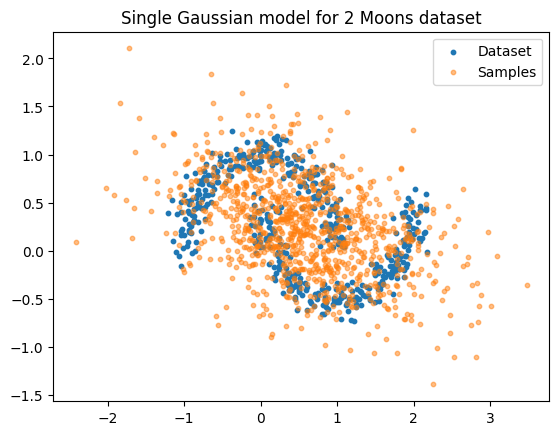

In [22]:
from scipy.stats import multivariate_normal

class single_gaussian:
    def __init__(self):
        self.mu = None
        self.Sigma = None
        self.samples = None
        self.score = None
        self.MMD_sq = None
        self.log_density = None
    # Method to fit a single Gaussian
    '''
    Need to determine appropriate mu, sigma for a single Gaussian on top of the data
    '''
    def fit(self, X): # training_data := X
        # Gaussian with simply mu = np.mean, Sigma = np.cov
        self.mu = np.mean(X, axis = 0)
        self.Sigma = np.cov(X, rowvar = False)

        return self.mu, self.Sigma
    
    def sample(self, n_samples):
        self.samples = np.random.multivariate_normal(self.mu, self.Sigma, n_samples)
        return self.samples

    def score_samples(self, X):
        """Compute the log density for each point in X."""
        if self.mu is None or self.Sigma is None:
            raise ValueError("Model parameters are not initialized. Call `fit` first.")

        # Compute the log density using the multivariate normal distribution
        self.log_density = multivariate_normal.logpdf(X, mean=self.mu, cov=self.Sigma)
        return self.log_density

    def compute_mmd(self, X, h = 1, kernel = "squared_exponential"):
        # Implement MMD^2 metric with se, imq kernels
        # Need to vectorize MMD calculation because for loops (sums) are very inefficient in python
        # MMD^2 = Term1 + Term2 - Term3, can neglect Term1 because it is model independent
        """
        MMD^2 = 0
        for i in range(1,N):
            for i_prime != i:
                MMD^2 += k(x_i, x_i_prime)

        for j in range(1, N_prime):
            for j_prime != j:
                MMD^2 += k(x_prime_j, x_prime_j_prime)

        for i in range(1, N):
            for j in range(1, N_prime):
                MMD^2 += -2 k(x_i, x_prime_j)
        """
        # Instead, we want to calculate it using something like this:
        """
        MMD^2 = k(distance_matrix_x).sum() 
            + k(distance_matrix_x_prime).sum() 
            - 2 k(distance_matrix_xx_prime).sum()
        """
        # Calculate Distance matrices D as: 
        # D[i, j] = || x_i - x_i_prime ||_2^2 = ||x||_2^2 + ||x_prime||_2^2 - 2 x.T @ x_prime
        # D_XX = self.calculate_distance_matrix(X, X) Can be neglected
        D_XprimeXprime = self.calculate_distance_matrix(self.samples, self.samples)
        D_XXprime = self.calculate_distance_matrix(X, self.samples)

        # Depending on selected kernel, calculate MMD^2
        N = X.shape[0]
        Nprime = self.samples.shape[0]
        if kernel == "squared_exponential":
            self.MMD_sq = (self.squared_exponential(D_XprimeXprime, h).sum() / (Nprime ** 2)
                      - 2 * self.squared_exponential(D_XXprime, h).sum() / (N * Nprime))
        elif kernel == "inverse_multi_quadratic":
            self.MMD_sq = (self.inverse_multi_quadratic(D_XprimeXprime, h).sum() / (Nprime ** 2)
                      - 2 * self.inverse_multi_quadratic(D_XXprime, h).sum() / (N * Nprime))
        else:
            raise ValueError("Please select either 'squared_exponential' or 'inverse_multi_quadratic'")
        """
        In the lecture we derived the formula where we sum over i, then sum over i != j. The kernels 
        k(i, i) are not 0, but 1. We still sum over them in the vectorization. For that reason, 
        we adjust the denominator to N^2, N'^2 instead of N(N-1), N'(N'-1)
        """

        self.MMD_sq

        return self.MMD_sq
    
    def calculate_distance_matrix(self, A, B):
        # D_ij = ||A_i - B_j||^2 = ||A_i||^2 + ||B_j||^2 - 2 A_i @ B_j.T
        # A_sq in (N_A, 1)
        A_sq = np.sum(A ** 2, axis = 1, keepdims = True)
        # B_sq in (1, N_B)
        B_sq = np.sum(B ** 2, axis = 1, keepdims = True).T # .T otherwise won't work if samples, data different dimension
        AB_T = A @ B.T
        D_AB = A_sq + B_sq - 2 * AB_T
        return D_AB
        
    def squared_exponential(self, D_AB, h):
        return exp(- D_AB / (h ** 2))   
    
    def inverse_multi_quadratic(self, D_AB, h):
        return 1 / sqrt(1 + D_AB / (h ** 2))

# Fit 2d single Gaussian model
model = single_gaussian()
make_moons_single_gaussian = model.fit(X)

# Sample from Gaussian
samples = model.sample(n_samples = 1000)
plt.figure()
plt.title("Single Gaussian model for 2 Moons dataset")
plt.scatter(X[:, 0], X[:, 1], s=10, 
            label = "Dataset")
plt.scatter(samples[:, 0], samples[:, 1],
            alpha = 0.5, 
            s = 10,
            label = "Samples")
plt.legend()
plt.show()

# Score

### 1.3 Gaussian Mixture Model

<div style="color: green; font-weight: bold">

#### OVERALL COMMENTS

FIT():

PREDICT()/SCORE_SAMPLES():

SAMPLE():

MMD2 and Model Evaluation:
- See Overall Comments above.
</div>

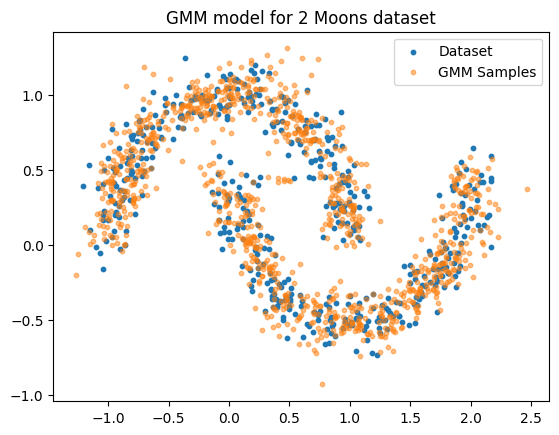

In [23]:
from scipy.stats import multivariate_normal

class gaussian_mixture_model:
    def __init__(self, n_terms = 1, steps = 100):
        self.mus = None
        self.Sigmas = None
        self.Pis = None
        self.samples = None
        self.score = None
        self.n_terms = n_terms
        self.steps = steps

    '''
    p_hat = sum_{m = 1}^M Pi_m N(mu_m, Sigma_m), where mu_m, Sigma_m
    can be found through expectation maximization algorithm from 1D.

    Basics:
    (0) Initialize Sigma_k = Id, mu_k random datapoint, Pi_k^(0) = 1 / M
    (1) for step t or until convergence:
        a) calc. performance
            gamma_ik^(t) = Pi_k^(t-1) N(x_i | mu_k^(t-1), Sigma_k^(t-1)) / p^(t-1)(x_i)
        b) update mu_k^(t), Sigma_k^(t)
            Pi_k^(t) = 1/N sum_{i=1}^N gamma_ik
            mu_k^(t) = sum_{i=1}^N gamma_ik x_i / sum_{i=1}^N gamma_ik
            Sigma_k^(t) ...
    '''

    def initialize_parameters(self, X):
        N, D = X.shape
        M = self.n_terms

        # Initialize for t = 0
        random_indices = np.random.choice(N, M, replace = False)
        self.mus = X[random_indices]
        self.Pis = np.ones(M) / M
        self.Sigmas = np.array([np.eye(D) for _ in range(M)])

    # Method to fit GMM
    def fit(self, X): # training_data := X
        
        # Initialize parameters
        self.initialize_parameters(X)
        self.N, self.D = X.shape
        self.M = self.n_terms

        # Expectation Maximization algorithm
        for t in range(self.steps):
            self.gamma_ik = np.zeros((self.N, self.M))
            # a) Calculate gamma_ik
            for k in range(self.M):
                self.gamma_ik[:, k] = self.Pis[k] * multivariate_normal.pdf(X, mean = self.mus[k], cov = self.Sigmas[k])

            # Normalize gamma_ik
            self.gamma_ik /= np.sum(self.gamma_ik, axis = 1, keepdims = True)
            
            # b) Update parameters
            # Calculate mus
            self.Pis = np.mean(self.gamma_ik, axis = 0)
            self.mus = (self.gamma_ik.T @ X) / np.sum(self.gamma_ik, axis = 0)[:, np.newaxis]
            # Calculate Sigmas: sum_i gamma_ik (x - mu)^T (x - mu) / sum_i gamma_ik
            # Define a small regularization constant to keep cov positive definite
            REG_COV = 1e-6
            for k in range(self.M):
                X_centered = X - self.mus[k]
                weighted_X_centered = X_centered * self.gamma_ik[:, k][:, np.newaxis]
                self.Sigmas[k] = weighted_X_centered.T @ X_centered / np.sum(self.gamma_ik[:, k], axis = 0) + REG_COV * np.eye(self.D)

        return self.mus, self.Sigmas
    
    def sample(self, n_samples):
        # Sample from GMM
        # 1. Pick from which Gaussian to sample based on weighs Pi_k
        component_indices = np.random.choice(self.M, size = n_samples, p = self.Pis)
        # Initialize samples array
        self.samples = np.zeros((n_samples, self.D))
        # 2. Sample from selected Gaussian
        for k in range(self.M):
            # Count instances where Gaussian k was selected
            n_k = np.sum(component_indices == k)
            if n_k > 0:
                self.samples[component_indices == k] = np.random.multivariate_normal(
                    self.mus[k], self.Sigmas[k], n_k)

        return self.samples
    
    # Method to score samplles
    def score_samples(self, X):
        """Compute the log density for each point in X."""
        if self.Pis is None or self.mus is None or self.Sigmas is None:
            raise ValueError("Model parameters are not initialized. Call `fit` first.")

        # Compute the weighted density for each component
        densities = np.zeros((X.shape[0], self.M))
        for k in range(self.M):
            densities[:, k] = self.Pis[k] * multivariate_normal.pdf(X, mean=self.mus[k], cov=self.Sigmas[k])

        # Sum the densities across components
        total_density = np.sum(densities, axis=1)

        # Return the log density
        log_density = np.log(total_density)
        return log_density

    # Method to evaluate
    def compute_mmd(self, X, h = 1, kernel = "squared_exponential"):
        # Implement MMD^2 metric with se, imq kernels
        # Need to vectorize MMD calculation because for loops (sums) are very inefficient in python
        # MMD^2 = Term1 + Term2 - Term3, can neglect Term1 because it is model independent
        """
        MMD^2 = 0
        for i in range(1,N):
            for i_prime != i:
                MMD^2 += k(x_i, x_i_prime)

        for j in range(1, N_prime):
            for j_prime != j:
                MMD^2 += k(x_prime_j, x_prime_j_prime)

        for i in range(1, N):
            for j in range(1, N_prime):
                MMD^2 += -2 k(x_i, x_prime_j)
        """
        # Instead, we want to calculate it using something like this:
        """
        MMD^2 = k(distance_matrix_x).sum() 
            + k(distance_matrix_x_prime).sum() 
            - 2 k(distance_matrix_xx_prime).sum()
        """
        # Calculate Distance matrices D as: 
        # D[i, j] = || x_i - x_i_prime ||_2^2 = ||x||_2^2 + ||x_prime||_2^2 - 2 x.T @ x_prime
        # D_XX = self.calculate_distance_matrix(X, X) Can be neglected
        D_XprimeXprime = self.calculate_distance_matrix(self.samples, self.samples)
        D_XXprime = self.calculate_distance_matrix(X, self.samples)

        # Depending on selected kernel, calculate MMD^2
        N = X.shape[0]
        Nprime = self.samples.shape[0]
        if kernel == "squared_exponential":
            MMD_sq = (self.squared_exponential(D_XprimeXprime, h).sum() / (Nprime ** 2)
                      - 2 * self.squared_exponential(D_XXprime, h).sum() / (N * Nprime))
        elif kernel == "inverse_multi_quadratic":
            MMD_sq = (self.inverse_multi_quadratic(D_XprimeXprime, h).sum() / (Nprime ** 2)
                      - 2 * self.inverse_multi_quadratic(D_XXprime, h).sum() / (N * Nprime))
        else:
            raise ValueError("Please select either 'squared_exponential' or 'inverse_multi_quadratic'")
        """
        In the lecture we derived the formula where we sum over i, then sum over i != j. The kernels 
        k(i, i) are not 0, but 1. We still sum over them in the vectorization. For that reason, 
        we adjust the denominator to N^2, N'^2 instead of N(N-1), N'(N'-1)
        """

        self.MMD_sq = MMD_sq

        return self.MMD_sq

    
    def calculate_distance_matrix(self, A, B):
        # D_ij = ||A_i - B_j||^2 = ||A_i||^2 + ||B_j||^2 - 2 A_i @ B_j.T
        # A_sq in (N_A, 1)
        A_sq = np.sum(A ** 2, axis = 1, keepdims = True)
        # B_sq in (1, N_B)
        B_sq = np.sum(B ** 2, axis = 1, keepdims = True).T # .T otherwise won't work if samples, data different dimension
        AB_T = A @ B.T
        D_AB = A_sq + B_sq - 2 * AB_T
        return D_AB
        
    def squared_exponential(self, D_AB, h):
        return exp(- D_AB / (h ** 2))   
    
    def inverse_multi_quadratic(self, D_AB, h):
        return 1 / sqrt(1 + D_AB / (h ** 2))

    

# Test GMM
model = gaussian_mixture_model(n_terms = 10, steps = 100)
make_moons_gmm = model.fit(X)

# Plot calculated GMM over data
samples = model.sample(1000)
plt.figure()
plt.title("GMM model for 2 Moons dataset")
plt.scatter(X[:, 0], X[:, 1], s=10, 
            label = "Dataset")
plt.scatter(samples[:, 0], samples[:, 1],
            alpha = 0.5, 
            s = 10, 
            label = "GMM Samples")
plt.legend()       
plt.show()

# Score

### Evaluation of Models


#### Steps:
1. Vary hyperparameters for each model (e.g., number of components for GMM).
2. Compute MMD for different bandwidths (`h`).
3. Visualize the results:
   - MMD values as a function of hyperparameters.
   - Density estimates and generated samples.

In [24]:
# Define data to train and test
X_train, _ = make_moons(n_samples = 1000, noise = 0.1, random_state = 42)
X_test, _ = make_moons(n_samples = 1000, random_state = 24)

#### 2D Histogram

/var/folders/dr/34chm7gn07vdb_w184vptt640000gn/T/ipykernel_94309/2696974575.py:98: RuntimeWarning: divide by zero encountered in log
  self.log_densities[valid_mask] = np.log(


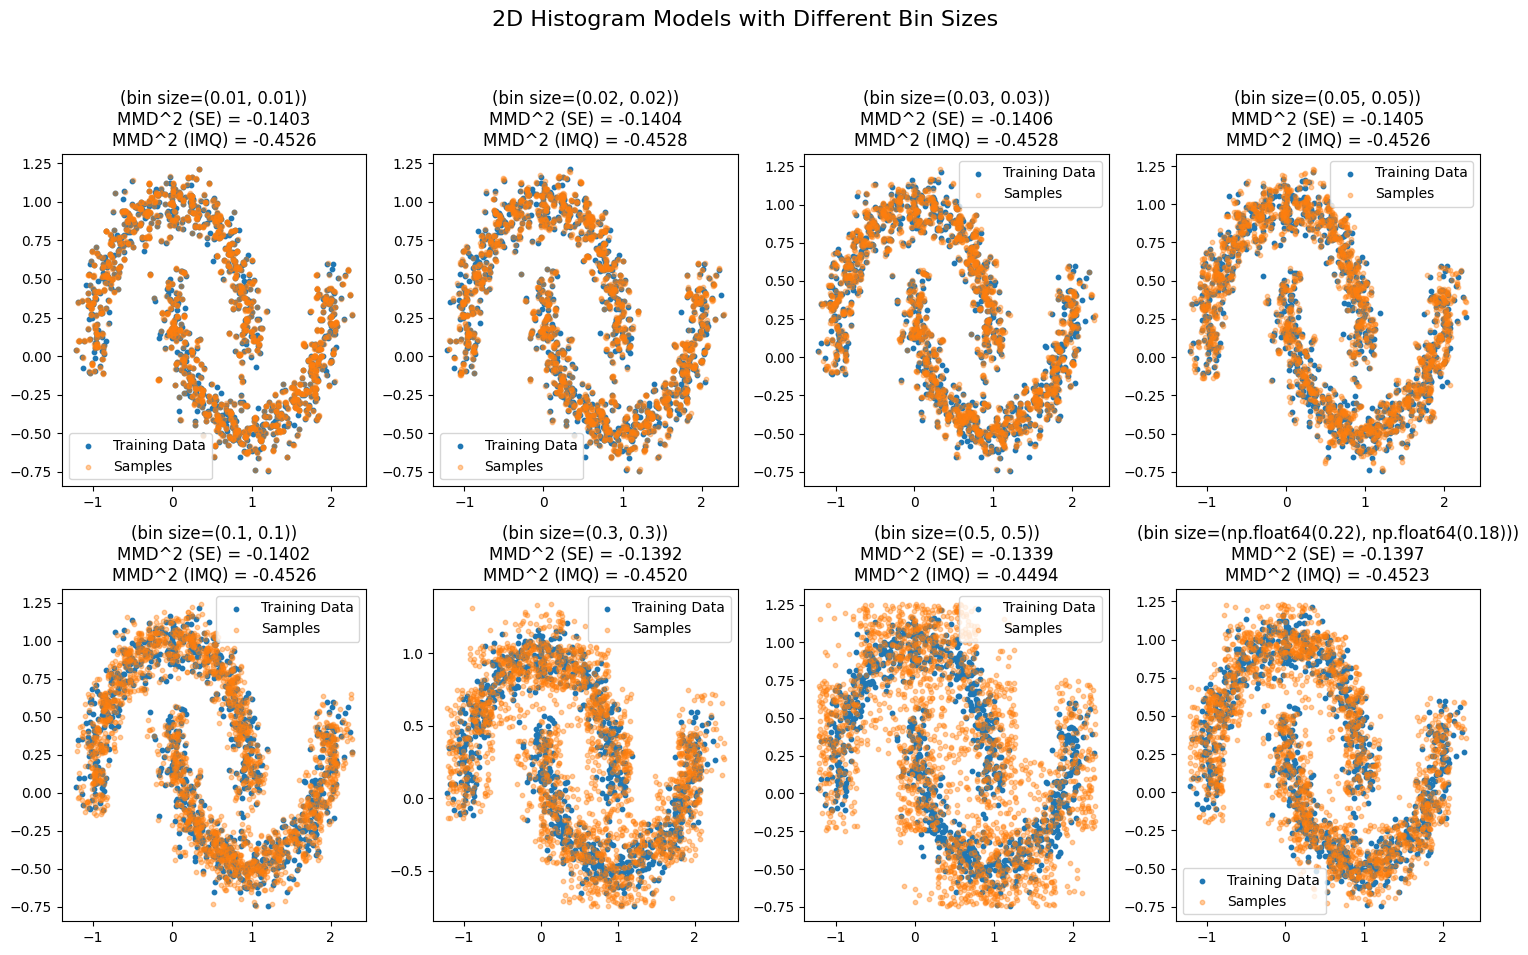

In [25]:
# Bin sizes
bin_sizes = [(0.01, 0.01), (0.02, 0.02), (0.03, 0.03), (0.05, 0.05), (0.1, 0.1), (0.3, 0.3), (0.5, 0.5), None]
results = {}
avg_bin_sizes = []
# Make a grid of plots
fig, axs = plt.subplots(2, 4, figsize=(15, 10))
fig.suptitle("2D Histogram Models with Different Bin Sizes", fontsize=16)
for bin_size in bin_sizes:
    model = two_dim_histogram(bin_size=bin_size)
    model.fit(X_train)
    model.sample(2000)
    model.score_samples(X_test)
    mmd_sq_se = model.compute_mmd(X_test, h = 0.5, kernel = "squared_exponential")
    mmd_sq_imq = model.compute_mmd(X_test, h = 0.5, kernel = "inverse_multi_quadratic")
    results[f"histogram_bin_size_{bin_size}"] = (mmd_sq_se, mmd_sq_imq)
    avg_bin_sizes.append(np.mean(model.bin_size))

    # Plotting
    ax = axs.flatten()[bin_sizes.index(bin_size)]
    X_samples = model.sample(n_samples = 2000)
    ax.scatter(X_train[:, 0], X_train[:, 1], s=10, label = "Training Data")
    ax.scatter(X_samples[:, 0], X_samples[:, 1], s=10, alpha = 0.4, label = "Samples")
    ax.set_title(f"(bin size={model.bin_size})\nMMD^2 (SE) = {mmd_sq_se:.4f}\nMMD^2 (IMQ) = {mmd_sq_imq:.4f}")
    ax.legend()

fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


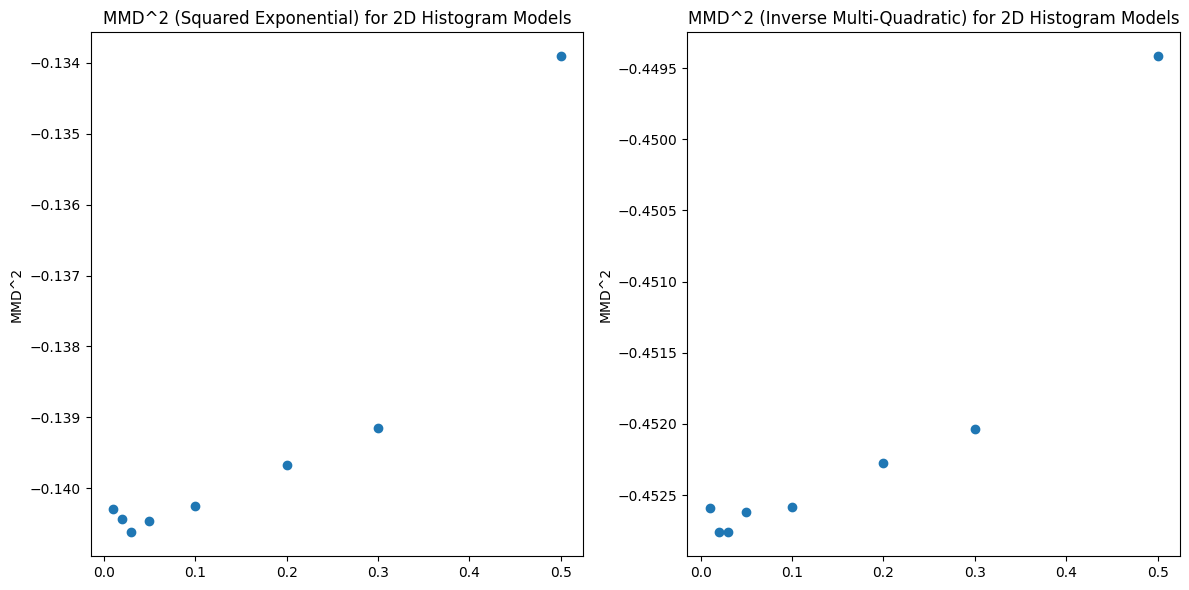

In [26]:
# Plot MMD^2 results for 2D histogram
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
# SE / IMQ
results_se = [results[key][0] for key in results]
results_imq = [results[key][1] for key in results]
axs[0].scatter(avg_bin_sizes, results_se)
axs[0].set_title("MMD^2 (Squared Exponential) for 2D Histogram Models")
axs[0].set_ylabel("MMD^2")
axs[1].scatter(avg_bin_sizes, results_imq)
axs[1].set_title("MMD^2 (Inverse Multi-Quadratic) for 2D Histogram Models")
axs[1].set_ylabel("MMD^2")
fig.tight_layout()
plt.show()

##### Comment on 2D Histogram results

Both kernels (se, imq) seem to find the same optimal solution among the selected ones at a bin_size of (0.05, 0.05) - (0.1, 0.1). Every run yields slightly different results, but consistently this range is among the best performing.

In 1d, the mathematically optimal solution calculates the Interquantile Range and determines from that the bin_size. In our case, it was of around (0.22, 0.18) which we plotted for simplicity purposes at an average of bin_size = 2. This does not seem to minimize the MMD^2 in two dimensions.

At a first glance, it appears as though bin_sizes that are too small overfit the model, so that it doesn't generalize when we use our test data.

<div style="color: green; font-weight: bold">
- See Overall Comments above.
- The bin_size calculated with IQR was approximated with bin_size = 0.2 (not =2!). 
</div>

#### GMM

-0.9262279844360581 -0.96419050977848
-0.9261870649893813 -0.9641780296817556
-0.9262069168700865 -0.9641878816807312
-0.9261699228907156 -0.9641705773061546
-0.9262235373788414 -0.9641957096301436
-0.926234296118036 -0.9642011115170642
-0.9262179129565649 -0.9641932940075044
-0.9262046441537343 -0.9641863369496917


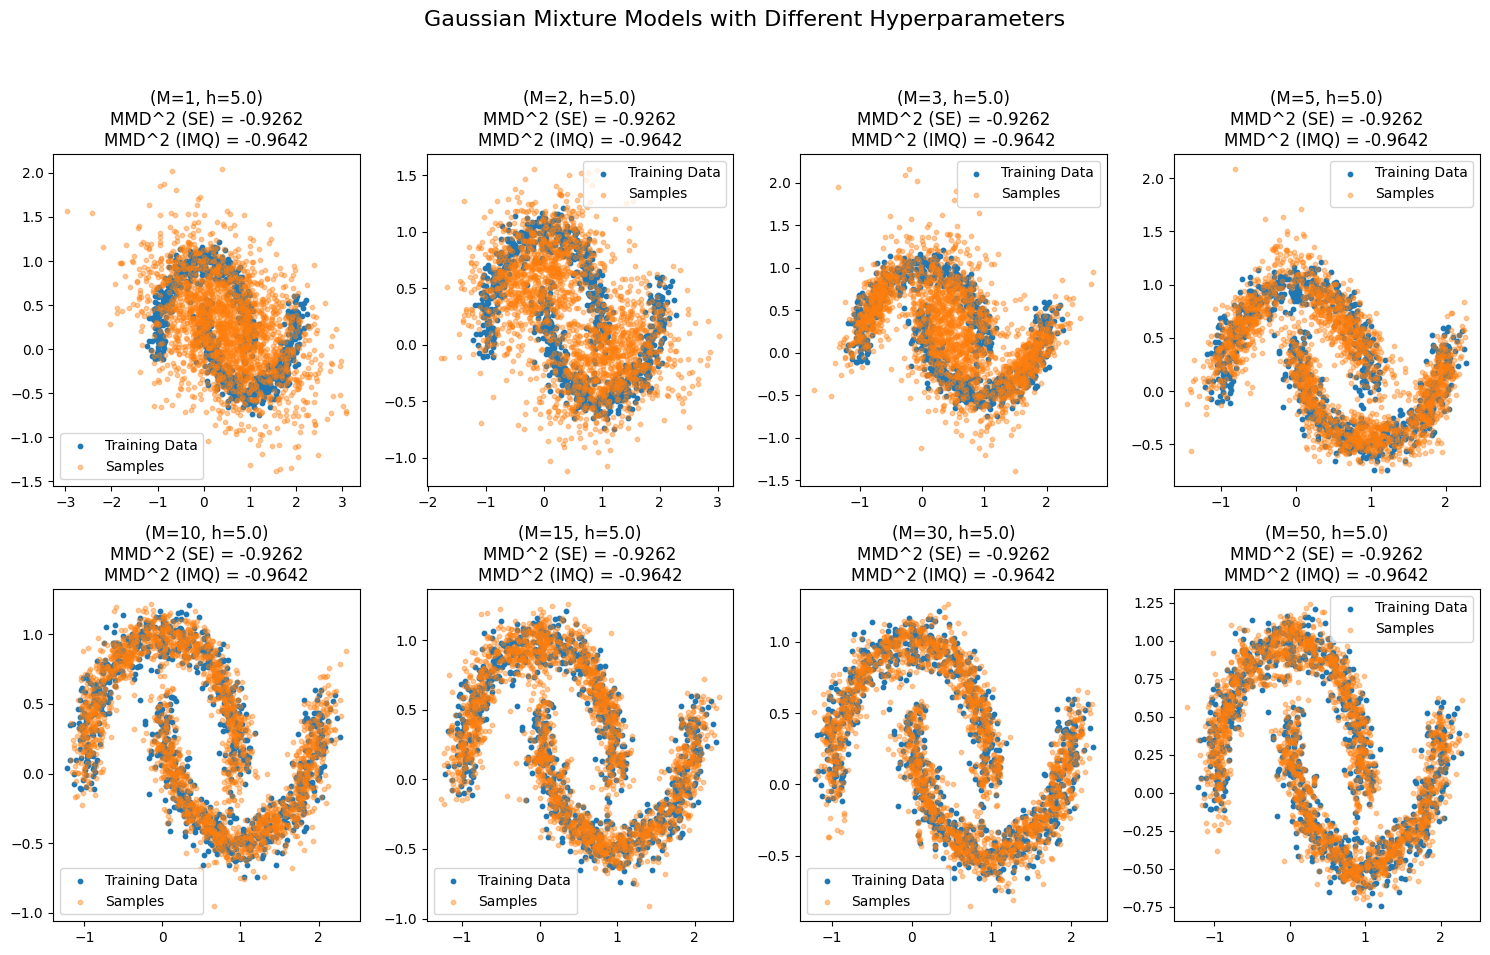

In [27]:
# Evaluate the GMM
# Bin sizes
Ms = [1, 2, 3, 5, 10, 15, 30, 50]
hs = [0.1, 0.2, 0.3, 0.5, 1.0, 1.5, 3.0, 5.0]

results = {}
# Make a grid of plots
fig, axs = plt.subplots(2, 4, figsize=(15, 10))
fig.suptitle("Gaussian Mixture Models with Different Hyperparameters", fontsize=16)
for M in Ms:
    for h in hs:
        model = gaussian_mixture_model(n_terms=M, steps=100)
        model.fit(X_train)
        model.sample(2000)
        model.score_samples(X_test)
        mmd_sq_se = model.compute_mmd(X_test, h=h, kernel="squared_exponential")
        mmd_sq_imq = model.compute_mmd(X_test, h=h, kernel="inverse_multi_quadratic")
        results[f"_{M}_{h}"] = (mmd_sq_se, mmd_sq_imq)
        if h == 5.0:
            print(mmd_sq_se, mmd_sq_imq)

    # Plotting (This will only plot for the last bandwidth but idc)
    ax = axs.flatten()[Ms.index(M)]
    X_samples = model.sample(n_samples=2000)
    ax.scatter(X_train[:, 0], X_train[:, 1], s=10, label="Training Data")
    ax.scatter(X_samples[:, 0], X_samples[:, 1], s=10, alpha=0.4, label="Samples")
    ax.set_title(f"(M={M}, h={h})\nMMD^2 (SE) = {mmd_sq_se:.4f}\nMMD^2 (IMQ) = {mmd_sq_imq:.4f}")
    ax.legend()

fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


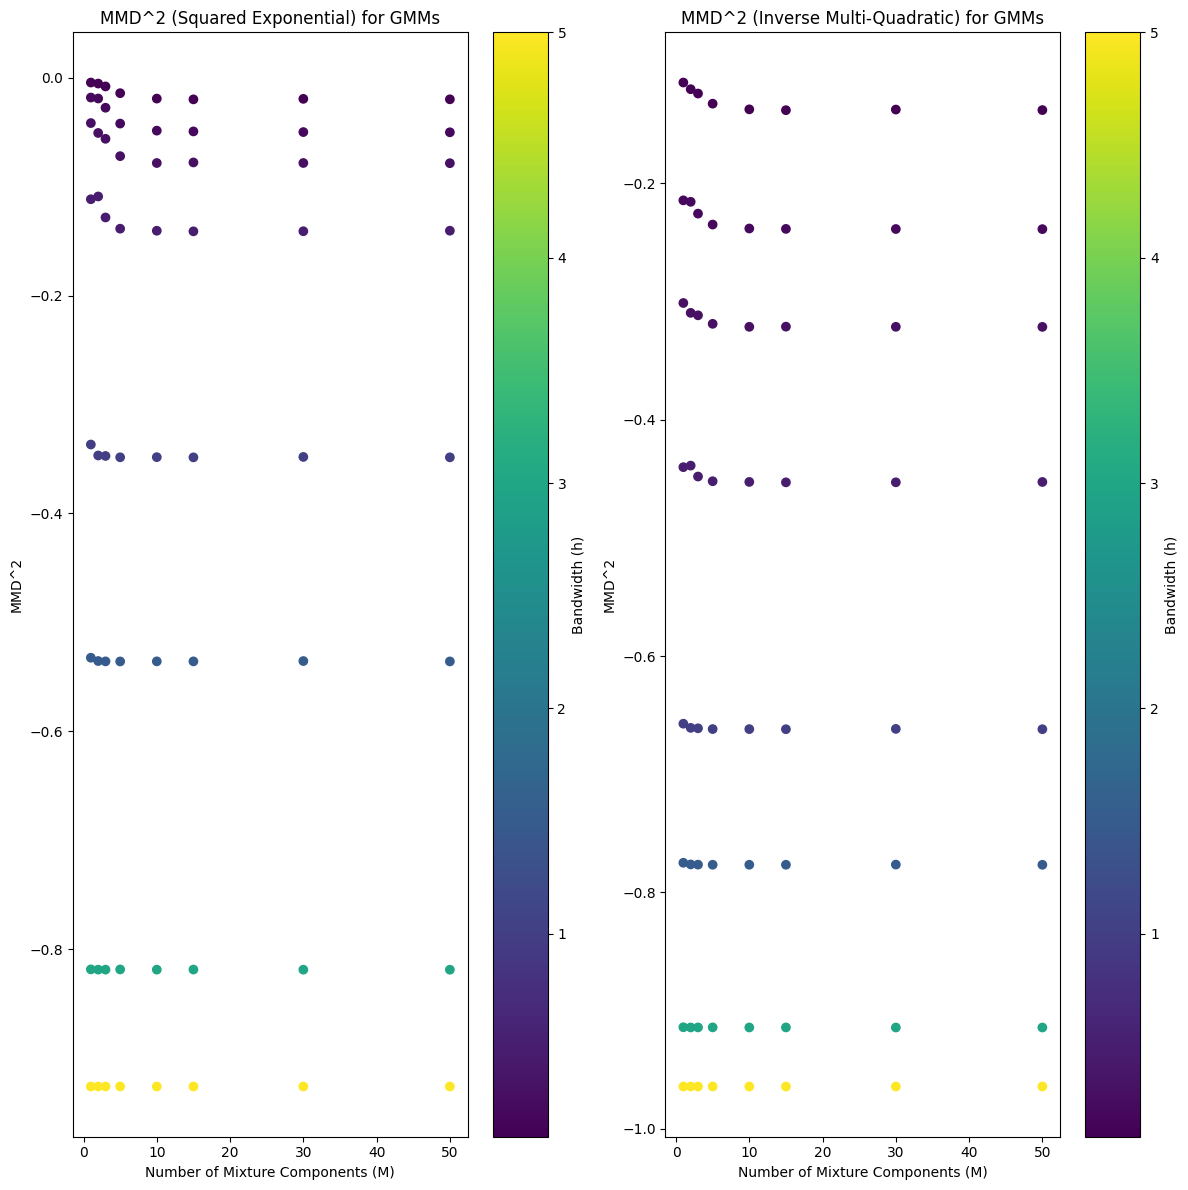

In [28]:
# Plot MMD^2 results for GMM
fig, axs = plt.subplots(1, 2, figsize=(12, 12))
# SE / IMQ
results_se = [results[key][0] for key in results]
results_imq = [results[key][1] for key in results]
Ms_list = [int(key.split("_")[1]) for key in results]
hs_list = [float(key.split("_")[2]) for key in results]
scatter1 = axs[0].scatter(Ms_list, results_se, c=hs_list, cmap='viridis')
axs[0].set_title("MMD^2 (Squared Exponential) for GMMs")
axs[0].set_xlabel("Number of Mixture Components (M)")
axs[0].set_ylabel("MMD^2")
cbar1 = fig.colorbar(scatter1, ax=axs[0])
cbar1.set_label('Bandwidth (h)')
scatter2 = axs[1].scatter(Ms_list, results_imq, c=hs_list, cmap='viridis')
axs[1].set_title("MMD^2 (Inverse Multi-Quadratic) for GMMs")
axs[1].set_xlabel("Number of Mixture Components (M)")
axs[1].set_ylabel("MMD^2")
cbar2 = fig.colorbar(scatter2, ax=axs[1])
cbar2.set_label('Bandwidth (h)')
fig.tight_layout()
plt.show()

##### Comment on GMM results

There are now multiple dimensions to this, because we test the model for different numbers of components and different bandwidths. We first comment on the total number of components, where at some point all models seem to converge. However, the models with larger bandwidth converge much faster which is totally weird because obviously for a small number of Gaussian terms, the model does not generalize well. Maybe a mistake in our calculation.

<div style="color: green; font-weight: bold">
- See Overall Comments above.
- The faster convergence of the MMD^2 values to a constant level for larger h can be explained by oversmoothing (see above). 
</div>

### KDE

<div style="color: green; font-weight: bold">

#### OVERALL COMMENTS
This is our solution for the KDE model. (1.4) It's there, yet it lacked some comments and explanations. That we can do now. YEEEEHAW

FIT():

PREDICT()/SCORE_SAMPLES():

SAMPLE():

MMD2 and Model Evaluation:
- See Overall Comments above.
- For this model, we did not implement MMD2 calculation. Hence, it can only be evaluated by visual inspection of the density estimates and samples. As mentioned above, implementing a global MMD2 function would have been more efficient. 
</div>

In [29]:
# Kernel Density Estimation (KDE) with cross-validated bandwidth selection
def my_bw_method(X, grid=None, ref_covar=1e-6, weights=None, cv=5, random_state=None):
    """
    K-fold cross-validation selector for a scalar bandwidth multiplier b.
    Returns b that maximizes held-out log-likelihood (sum of log pdfs on folds).
    - X : array (n, d)
    - grid : iterable of candidate b values (optional)
    - ref_covar : small diagonal regularizer added to covariance
    - weights : optional sample weights (not used for splitting)
    - cv : int number of folds (use cv=n for leave-one-out)
    - random_state : int or RandomState for shuffling folds
    """
    import math
    from sklearn.model_selection import KFold

    X = np.asarray(X)
    n, d = X.shape
    if n < 2:
        return 1.0

    if grid is None:
        grid = np.logspace(-2, 1, 30)

    def logsumexp(a, axis=None):
        a_max = np.max(a, axis=axis, keepdims=True)
        s = np.log(np.sum(np.exp(a - a_max), axis=axis, keepdims=True)) + a_max
        return np.squeeze(s, axis=axis)

    kf = KFold(n_splits=min(cv, n), shuffle=True, random_state=random_state)
    best_b = None
    best_score = -np.inf

    # loop over candidate scalar bandwidth multipliers b
    for b in grid:
        total_val_loglik = 0.0
        valid_b = True
        for train_idx, val_idx in kf.split(X):
            X_train = X[train_idx]
            X_val = X[val_idx]
            m_train = X_train.shape[0]
            if m_train < 1:
                valid_b = False
                break

            # training fold covariance (fall back to tiny identity if degenerate)
            S = np.cov(X_train.T, bias=False) if X_train.shape[0] > 1 else np.eye(d) * 1e-8
            cov = (b ** 2) * S + ref_covar * np.eye(d)
            try:
                inv_cov = np.linalg.inv(cov)
                sign, logdet = np.linalg.slogdet(cov)
                if sign <= 0:
                    valid_b = False
                    break
            except np.linalg.LinAlgError:
                valid_b = False
                break

            # Mahalanobis distances between validation points and train points: shape (n_val, m_train)
            diff = X_val[:, None, :] - X_train[None, :, :]  # (n_val, m_train, d)
            m = np.einsum('ijk,kl,ijl->ij', diff, inv_cov, diff)  # (n_val, m_train)

            # kernel log-values
            log_k = -0.5 * m
            # normalization constant for gaussian kernel in d dims
            log_norm = (d / 2.0) * np.log(2.0 * math.pi) + 0.5 * logdet

            # compute log pdf for each validation point: log( (1/m_train) sum_j exp(log_k_ij) ) - log_norm
            with np.errstate(over='ignore'):
                row_logsum = logsumexp(log_k, axis=1)  # (n_val,)
            logpdf_val = row_logsum - np.log(max(m_train, 1)) - log_norm
            total_val_loglik += np.sum(logpdf_val)

        if not valid_b:
            continue

        if total_val_loglik > best_score:
            best_score = total_val_loglik
            best_b = b

    return float(best_b if best_b is not None else 1.0)


class KDE:
    def __init__(self,
                 bandwidth=None,        
                 bw_method='scott',     #we will use my_bw_method as bw_method, but as a default it's 'scott', which is faster
                 covariance_type='full',
                 kernel='gaussian',
                 ref_covar=1e-6,
                 weights=None,
                 random_state=None):
        #storing the parameters for the beginning
        self.bandwidth = bandwidth
        self.bw_method = bw_method
        self.covariance_type = covariance_type
        self.kernel = kernel
        self.ref_covar = float(ref_covar)
        self.weights = weights

        weights = None if weights is None else np.asarray(weights, dtype=float)
        self.random_state = (np.random.RandomState(random_state)
                             if random_state is not None else np.random)

        # attributes set by fit()
        self.is_fitted_ = False
        self.dataset_ = None
        self.n_samples_ = 0
        self.n_features_ = None
        self.mean_ = None
        self.covariance_ = None    # global kernel covariance
        self.inv_covariance_ = None
        self.log_det_cov_ = None
        self.bandwidth_ = None     # scalar multiplier if used

    def _compute_sample_cov(self, X):
        # unweighted sample covariance, standadr sample covariance
        return np.cov(X.T, bias=False)
        

    def fit(self, X):
        X = np.asarray(X)
        if X.ndim != 2:
            raise ValueError("X must be shape (n_samples, n_features)")
        n, d = X.shape
        self.dataset_ = X.copy()
        self.n_samples_ = n
        self.n_features_ = d
        self.mean_ = X.mean(axis=0)

        # compute sample covariance, captures spread of data
        S = self._compute_sample_cov(X)  
        # decide bandwidth / covariance
        cov = None
        # if bandwidth given explicitly as 2x2 matrix-like, use it directly
        if self.bandwidth is not None and np.shape(self.bandwidth) == (d, d):
            cov = np.array(self.bandwidth, dtype=float)
            self.bandwidth_ = None
        # if bandwidth doesnt have the right shape, build it like this    
        else:
            # scalar bandwidth decision
            if self.bandwidth is not None and np.isscalar(self.bandwidth):
                b = float(self.bandwidth)
            else:
                # choose via bw_method
                if callable(self.bw_method):
                    # pass cv and ref_covar through if function supports them (my_bw_method does)
                    b = float(self.bw_method(X, ref_covar=self.ref_covar, cv=max(2, min(n, 5)), random_state=None))
                else:
                    raise ValueError("unknown bw_method: %r" % (self.bw_method,))
                self.bandwidth_ = b
            cov = (b ** 2) * S + self.ref_covar * np.eye(d)
        final_cov = cov
        # apply covariance_type reductions, we will use spherical for euclidian distances, but having the others is practical
        if self.covariance_type == 'spherical':
            # final_cov == s * I -> Euclidean distances (isotropic Gaussian)
            s = np.mean(np.diag(final_cov))
            sigma2 = float(s)
            # inverse covariance is (1/sigma2) * I
            inv_cov = np.eye(d) / sigma2
            # log determinant = d * log(sigma2)
            logdet = d * np.log(sigma2)
        else:
            # robust full/diag handling via Cholesky (more stable than direct inv)
            try:
                L = np.linalg.cholesky(final_cov)
            except np.linalg.LinAlgError:
                # regularize and retry
                final_cov = final_cov + max(self.ref_covar, 1e-12) * np.eye(d)
                L = np.linalg.cholesky(final_cov)
            # compute logdet from Cholesky and inverse via solves
            logdet = 2.0 * np.sum(np.log(np.diag(L)))
            inv_cov = np.linalg.solve(L.T, np.linalg.solve(L, np.eye(d)))

        self.covariance_ = final_cov
        self.inv_covariance_ = inv_cov
        self.log_det_cov_ = float(logdet)
        self.is_fitted_ = True
        return self

    
    def score_samples(self, X):
        if not self.is_fitted_:
            raise RuntimeError("Call fit first")
        X = np.asarray(X)
        if X.ndim != 2 or X.shape[1] != self.n_features_:
            raise ValueError("X must be shape (n_samples, %d)" % self.n_features_)
        n = self.n_samples_
        d = self.n_features_

        # spherical -> use Euclidean distance (isotropic kernel)
        if self.covariance_type == 'spherical':
            # squared Euclidean distances between queries and training points
            diff = X[:, None, :] - self.dataset_[None, :, :]   # (m, n, d)
            sqdist = np.sum(diff * diff, axis=2)              # (m, n)

            # extract isotropic variance (should match fit logic)
            sigma2 = float(np.mean(np.diag(self.covariance_)))
            if sigma2 <= 0:
                sigma2 = max(sigma2, 1e-12)

            log_k = -0.5 * (sqdist / sigma2)
            log_norm = (d / 2.0) * np.log(2.0 * np.pi) + 0.5 * self.log_det_cov_
        else:
            raise ValueError("unknown covariance_type: %r" % (self.covariance_type,))
        
        
        # mixture weights / log-sum-exp, because we sum over exponentials of log-kernel values so they get changed
        def logsumexp(a, axis=None):
            a_max = np.max(a, axis=axis, keepdims=True)
            s = np.log(np.sum(np.exp(a - a_max), axis=axis, keepdims=True)) + a_max
            return np.squeeze(s, axis=axis)

        if getattr(self, "weights", None) is None:
            with np.errstate(over='ignore'):
                row_logsum = logsumexp(log_k, axis=1)  # (m,)
            logpdf = row_logsum - np.log(n) - log_norm
        else:
            logw = np.log(self.weights + 1e-20)
            log_k_w = log_k + logw[None, :]
            with np.errstate(over='ignore'):
                row_logsum = logsumexp(log_k_w, axis=1)
            logpdf = row_logsum - log_norm

        return logpdf


    def sample(self, n_samples=1):
        #Draw samples from KDE: pick training points according to weights (or uniform),
         #  then add Gaussian noise with covariance=self.covariance_."""
        if not self.is_fitted_:
            raise RuntimeError("Call fit first")
        n = self.n_samples_
        if self.weights is None:
            probs = None
        else:
            probs = self.weights

        # choose component indices
        if probs is None:
            idx = self.random_state.randint(0, n, size=n_samples)
        else:
            idx = self.random_state.choice(np.arange(n), size=n_samples, p=probs)

        base = self.dataset_[idx]

        # draw Gaussian noise with covariance_
        try:
            L = np.linalg.cholesky(self.covariance_)  # lower-triangular
        except np.linalg.LinAlgError:
            # fallback: add tiny jitter
            L = np.linalg.cholesky(self.covariance_ + 1e-8 * np.eye(self.n_features_))

        z = self.random_state.randn(n_samples, self.n_features_)
        noise = z @ L.T  # (n_samples, d)
        samples = base + noise
        return samples

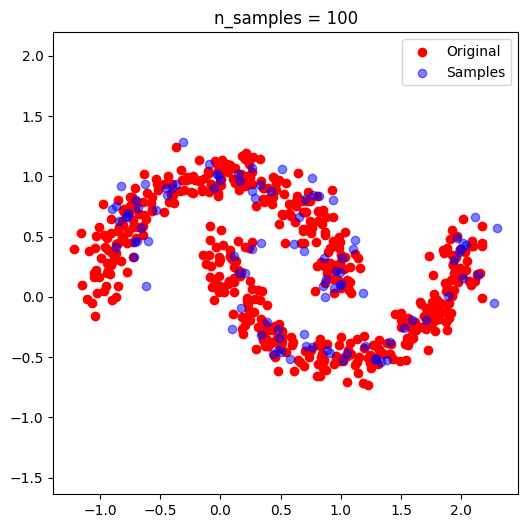

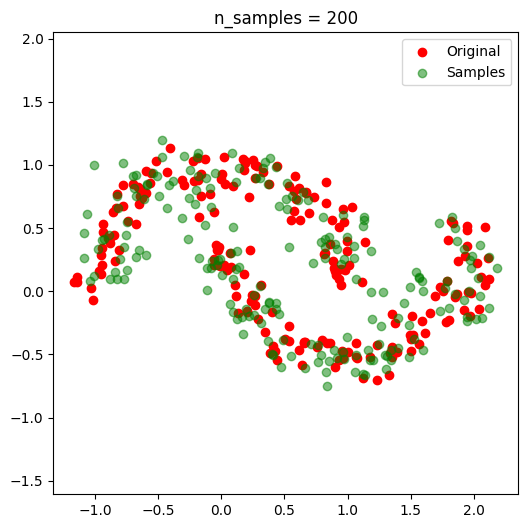

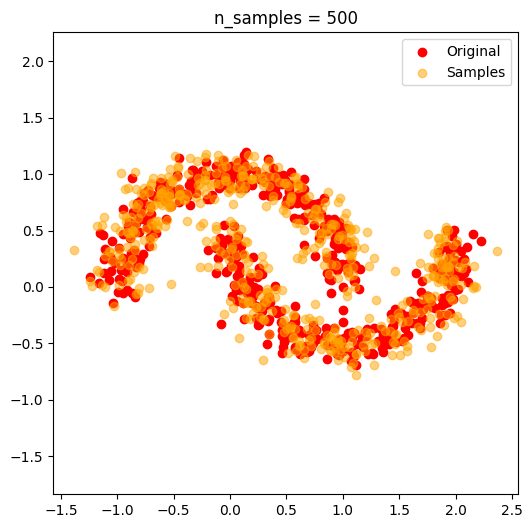

In [30]:
x1, y1 = make_moons(n_samples=500, noise=0.1, random_state=42)
x2, y2 = make_moons(n_samples=200, noise=0.1)
x5, y5 = make_moons(n_samples=500, noise=0.1)

#create the KDE objects and fit them to the data
kde1 = KDE(bw_method=my_bw_method, random_state=42)
kde1.fit(x1)                # just pass X
samples1 = kde1.sample(100)

kde2 = KDE(bw_method=my_bw_method, random_state=42)
kde2.fit(x2)
samples2 = kde2.sample(200)

kde5 = KDE(bw_method=my_bw_method, random_state=42)
kde5.fit(x5)
samples5 = kde5.sample(500)


# First dataset with 100 samples
plt.figure(figsize=(6,6))
plt.scatter(x1[:,0], x1[:,1], color='red', label='Original')
plt.scatter(samples1[:,0], samples1[:,1], color='blue', alpha=0.5, label='Samples')
plt.title("n_samples = 100")
plt.axis('equal')
plt.legend()
plt.show()

# Second dataset with 200 samples
plt.figure(figsize=(6,6))
plt.scatter(x2[:,0], x2[:,1], color='red', label='Original')
plt.scatter(samples2[:,0], samples2[:,1], color='green', alpha=0.5, label='Samples')
plt.title("n_samples = 200")
plt.axis('equal')
plt.legend()
plt.show()

# Third dataset with 500 samples
plt.figure(figsize=(6,6))
plt.scatter(x5[:,0], x5[:,1], color='red', label='Original')
plt.scatter(samples5[:,0], samples5[:,1], color='orange', alpha=0.5, label='Samples')
plt.title("n_samples = 500")
plt.axis('equal')
plt.legend()
plt.show()


# 2. Higher dimensional data

In [31]:
# Import dataset
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()
X, y = digits.data, digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
# Import Models
from sklearn.ensemble import RandomForestClassifier # In addition
from sklearn.neighbors import KDTree
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity

In [33]:
# Fit the models
# KDTree (instead of 2d Histogram)
kdtree = KDTree(X_train)
# GMM
gmm_10 = GaussianMixture(n_components=10, random_state=42)
gmm_10.fit(X_train)
gmm_100 = GaussianMixture(n_components=100, random_state=42)
gmm_100.fit(X_train)
# KDE
kde = KernelDensity(kernel='gaussian', bandwidth=1.0)
kde.fit(X_train)
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
# Sample
n_samples = 1000
# KDTree Sampling
dist, indices = kdtree.query(X_train[np.random.choice(X_train.shape[0], n_samples)], k=1)
kdtree_samples = X_train[indices.flatten()]
# GMM Sampling
gmm_10_samples, _ = gmm_10.sample(n_samples)
gmm_100_samples, _ = gmm_100.sample(n_samples)
# KDE Sampling
kde_samples = kde.sample(n_samples)
# Random Forest Sampling
rf_samples = rf.apply(X_train[np.random.choice(X_train.shape[0], n_samples)])
rf_samples = X_train[rf_samples[:, 0]]  # Using the first tree for sampling

In [35]:
# Compute MMD^2
def compute_mmd(X, h = 1, kernel = "squared_exponential"):
    # Implement MMD^2 metric with se, imq kernels
    # Need to vectorize MMD calculation because for loops (sums) are very inefficient in python
    # MMD^2 = Term1 + Term2 - Term3, can neglect Term1 because it is model independent
    """
    MMD^2 = 0
    for i in range(1,N):
        for i_prime != i:
            MMD^2 += k(x_i, x_i_prime)

    for j in range(1, N_prime):
        for j_prime != j:
            MMD^2 += k(x_prime_j, x_prime_j_prime)

    for i in range(1, N):
        for j in range(1, N_prime):
            MMD^2 += -2 k(x_i, x_prime_j)
    """
    # Instead, we want to calculate it using something like this:
    """
    MMD^2 = k(distance_matrix_x).sum() 
        + k(distance_matrix_x_prime).sum() 
        - 2 k(distance_matrix_xx_prime).sum()
    """
    # Calculate Distance matrices D as: 
    # D[i, j] = || x_i - x_i_prime ||_2^2 = ||x||_2^2 + ||x_prime||_2^2 - 2 x.T @ x_prime
    # D_XX = self.calculate_distance_matrix(X, X) Can be neglected
    D_XprimeXprime = calculate_distance_matrix(samples, samples)
    D_XXprime = calculate_distance_matrix(X, samples)

    # Depending on selected kernel, calculate MMD^2
    N = X.shape[0]
    Nprime = samples.shape[0]
    if kernel == "squared_exponential":
        MMD_sq = (squared_exponential(D_XprimeXprime, h).sum() / (Nprime ** 2)
                    - 2 * squared_exponential(D_XXprime, h).sum() / (N * Nprime))
    elif kernel == "inverse_multi_quadratic":
        MMD_sq = (inverse_multi_quadratic(D_XprimeXprime, h).sum() / (Nprime ** 2)
                    - 2 * inverse_multi_quadratic(D_XXprime, h).sum() / (N * Nprime))
    else:
        raise ValueError("Please select either 'squared_exponential' or 'inverse_multi_quadratic'")
    """
    In the lecture we derived the formula where we sum over i, then sum over i != j. The kernels 
    k(i, i) are not 0, but 1. We still sum over them in the vectorization. For that reason, 
    we adjust the denominator to N^2, N'^2 instead of N(N-1), N'(N'-1)
    """

    return MMD_sq

def calculate_distance_matrix(A, B):
    # D_ij = ||A_i - B_j||^2 = ||A_i||^2 + ||B_j||^2 - 2 A_i @ B_j.T
    # A_sq in (N_A, 1)
    A_sq = np.sum(A ** 2, axis = 1, keepdims = True)
    # B_sq in (1, N_B)
    B_sq = np.sum(B ** 2, axis = 1, keepdims = True).T # .T otherwise won't work if samples, data different dimension
    AB_T = A @ B.T
    D_AB = A_sq + B_sq - 2 * AB_T
    return D_AB

def squared_exponential(D_AB, h):
    return exp(- D_AB / (h ** 2))

def inverse_multi_quadratic(D_AB, h):
    return 1 / sqrt(1 + D_AB / (h ** 2))


In [36]:
# Compute MMD^2 for each model
models_samples = {
    "KDTree": kdtree_samples,
    "GMM_10": gmm_10_samples,
    "GMM_100": gmm_100_samples,
    "KDE": kde_samples
}

mmd_results = {}
for model_name, samples in models_samples.items():
    mmd_sq_se = compute_mmd(X_test, h = 1.0, kernel = "squared_exponential")
    mmd_sq_imq = compute_mmd(X_test, h = 1.0, kernel = "inverse_multi_quadratic")
    mmd_results[model_name] = (mmd_sq_se, mmd_sq_imq)

print("MMD^2 Results for Different Models:")
for model_name, (mmd_se, mmd_imq) in mmd_results.items():
    print(f"{model_name}: MMD^2 (SE) = {mmd_se:.4f}, MMD^2 (IMQ) = {mmd_imq:.4f}")

MMD^2 Results for Different Models:
KDTree: MMD^2 (SE) = 0.0018, MMD^2 (IMQ) = -0.0198
GMM_10: MMD^2 (SE) = 0.0010, MMD^2 (IMQ) = -0.0204
GMM_100: MMD^2 (SE) = 0.0010, MMD^2 (IMQ) = -0.0205
KDE: MMD^2 (SE) = 0.0010, MMD^2 (IMQ) = -0.0204


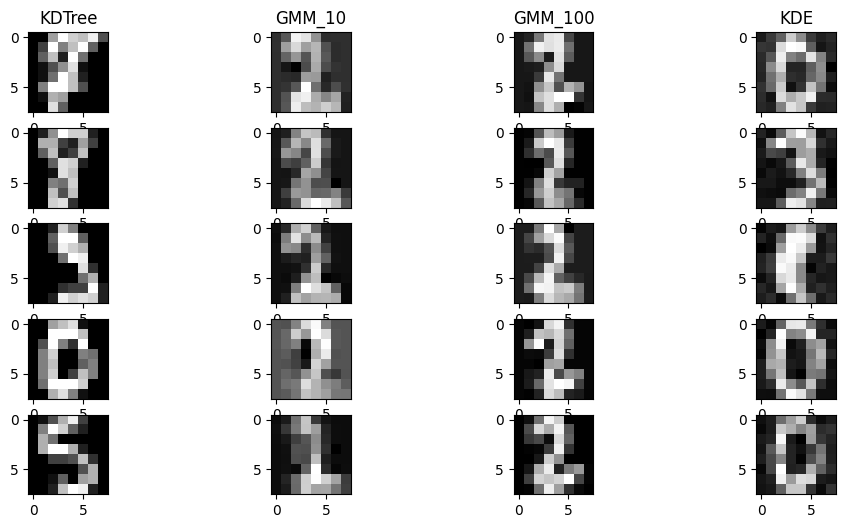

In [37]:
# Plot examples 
fig, axs = plt.subplots(5, 4, figsize=(12, 6))
for i in range(4):
    model_name = list(models_samples.keys())[i]
    samples = models_samples[model_name]
    for j in range(5):
        axs[j, i].imshow(samples[j].reshape(8, 8), cmap='gray')

        if j == 0:
            axs[0, i].set_title(f"{model_name}")

In [38]:
# Check model accuracy with RF
# Print score, accuracy
print("Random Forest Classifier Accuracy on Test Set:", rf.score(X_test, y_test))

Random Forest Classifier Accuracy on Test Set: 0.9722222222222222


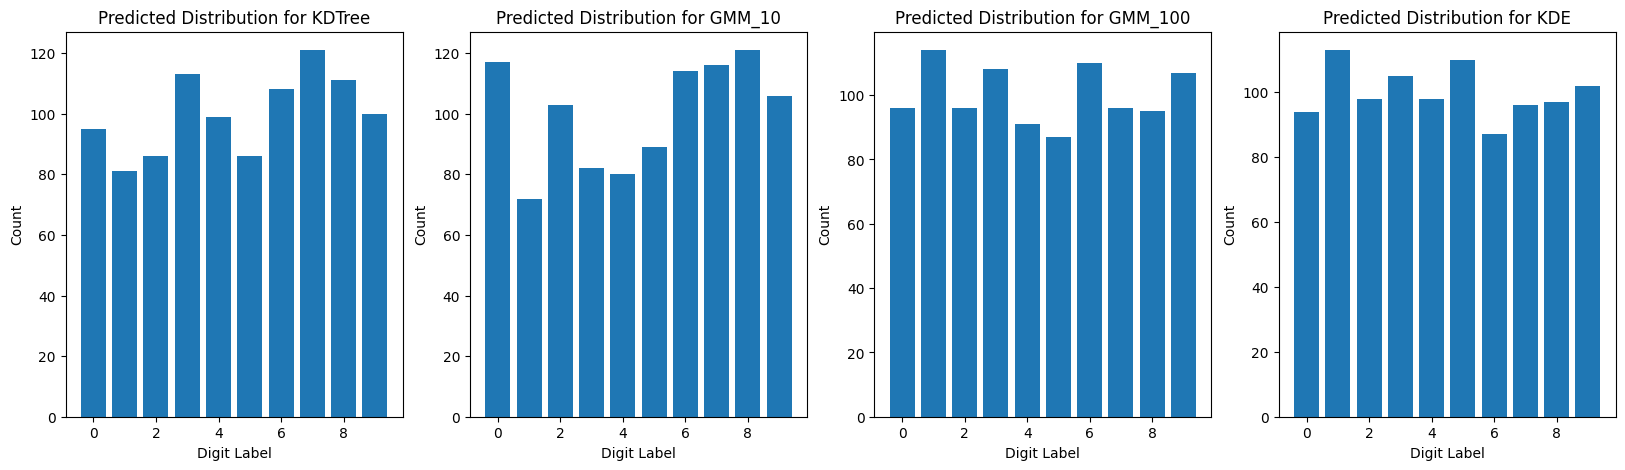

In [39]:
# Predict labels from data generated by models with RF
y_hats_models = {
    model_name: rf.predict(samples) for model_name, samples in models_samples.items()
}

# Show if uniformly distributed
y_hats_counts = {
    model_name: np.bincount(y_hats, minlength = 10) for model_name, y_hats in y_hats_models.items()
}

# Make some bar charts
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
for i in range(4):
    model_name = list(y_hats_counts.keys())[i]
    counts = y_hats_counts[model_name]
    axs[i].bar(range(10), counts)
    axs[i].set_title(f"Predicted Distribution for {model_name}")
    axs[i].set_xlabel("Digit Label")
    axs[i].set_ylabel("Count")
plt.show()


In [40]:
# Perform hypothesis test on each distribution
from scipy.stats import chisquare
alpha = 0.05
for model_name, counts in y_hats_counts.items():
    chi2_stat, p_value = chisquare(counts)
    print(f"{model_name}: Chi2 Stat = {chi2_stat:.4f}, p-value = {p_value:.4f}")
    if p_value < alpha:
        print(f"  Reject null hypothesis for {model_name}")
    else:
        print(f"  Fail to reject null hypothesis for {model_name}.")

KDTree: Chi2 Stat = 15.7400, p-value = 0.0725
  Fail to reject null hypothesis for KDTree.
GMM_10: Chi2 Stat = 28.5600, p-value = 0.0008
  Reject null hypothesis for GMM_10
GMM_100: Chi2 Stat = 7.3200, p-value = 0.6038
  Fail to reject null hypothesis for GMM_100.
KDE: Chi2 Stat = 5.3600, p-value = 0.8019
  Fail to reject null hypothesis for KDE.


#### Comment on results



Upon visual inspection, it is clear that the GMM model with only 10 Gaussian terms does not generalize well to the data and it returns very uneven results, having nearly twice as many "0" labels as "1" labels. The GMM model with 100 Gaussian terms fairs much better in comparison and the KDE distribution is also fairly equal. Visually, it is not clear whether the KDTree distribution passes the vibe check, but a simple chi^2 test yields that we can't reject the null hypothesis, although based on the p-value it is just slightly larger than our alpha value. Likely in a different run, the result could fall on either side.